In [1]:
%pip install -r requirements.txt

import numpy as np
import matplotlib.pyplot as plt
import os
import cv2
from typing import Tuple, List, Dict
# ==> modules
import convert_video

# ==> start working out how to display javascript & html pages in a notebook
from IPython.display import HTML, display

# ==> explore alternative - 
# from IPython.display import Video


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


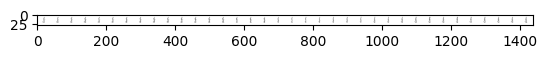

(42, 30, 1440)


In [5]:
v = np.load('/home/thomas/Desktop/dashboard/files-wr-36/video_gray.npy')
plt.imshow(v[2,:,:], cmap='gray')
plt.show()
print(v.shape)

In [6]:
# ==> run data preparation scripts
%run convert_beta_masks.py
%run convert_video.py --video-path files-wr-36/video_gray.npy --m 1 --n 36 --num-parameters 10 --output-dir thomas_results

(26, 26, 3, 951)
Saved to files/masks_array.npy
Loading your video file...
Loaded: (42, 30, 1440), uint8
\nConverting to app format...
Processing video array: (42, 30, 1440) (uint8)
Converted video shape: (42, 30, 1440) -> (30, 1440, 1, 42)
Converting to uint8: uint8 -> uint8
Original range: 97.000 to 255.000
Already uint8, skipping conversion
Final video shape: (30, 1440, 1, 42) (uint8)
\n=== Files Created ===
thomas_results/video_gr_prepped_video.npy: (30, 1440, 1, 42) (uint8)
\nReady to upload to the web app!


In [4]:
from IPython.display import IFrame, display
import subprocess
import time
import os
import socket

def is_server_running(port=8000):
    with socket.socket(socket.AF_INET, socket.SOCK_STREAM) as s:
        return s.connect_ex(('localhost', port)) == 0

# Start server if not running
if not is_server_running(8000):
    server = subprocess.Popen(
        ['python3', '-m', 'http.server', '8000'],
        stdout=subprocess.DEVNULL,
        stderr=subprocess.DEVNULL
    )
    time.sleep(1.5)
    print("Server started at http://localhost:8000/index4.html")
else:
    print("Server already running at http://localhost:8000/index4.html")

# Display the visualization
display(IFrame('http://localhost:8000/index4.html', width='100%', height=850))

# scp -r ~/Desktop/dashboard ubuntu@tal.cpl-experiments.org:/home/ubuntu/

# # 1. SSH into server
# ssh ubuntu@tal.cpl-experiments.org

# sudo apt install nginx

# # 2. Copy dashboard to web directory
# sudo cp -r /home/ubuntu/dashboard /var/www/html/

# # 3. Set proper permissions (important!)
# sudo chown -R www-data:www-data /var/www/html/dashboard
# sudo chmod -R 755 /var/www/html/dashboard

# # 4. If nginx is installed and running
# # Access at: http://tal.cpl-experiments.org/dashboard/index4.html

Server started at http://localhost:8000/index4.html
